In [1]:
from google.colab import files

uploaded = files.upload()

Saving paysim_cleaned_sample.csv to paysim_cleaned_sample.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("paysim_cleaned_sample.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (100000, 13)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrig', 'newbalanceOrig', 'errorBalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,errorBalanceOrig,nameDest,oldbalanceDest,newbalanceDest,errorBalanceDest,isFraud,isFlaggedFraud
0,304,CASH_OUT,468120.16,C1364834432,0.0,0.00,-468120.16,C112352648,1360189.05,1828309.21,0.00,0,0
1,281,CASH_OUT,39333.80,C1054357434,0.0,0.00,-39333.80,C302256535,50396.47,89730.27,0.00,0,0
2,302,PAYMENT,2017.48,C1126776883,0.0,0.00,-2017.48,M2111082372,0.00,0.00,2017.48,0,0
3,189,CASH_OUT,185360.25,C2088073298,7910.0,0.00,-177450.25,C305827266,432472.81,617833.06,0.00,0,0
4,371,CASH_IN,198845.02,C755566099,20965.0,219810.02,-397690.04,C1599740311,295959.49,97114.46,397690.05,0,0


In [ ]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   step              100000 non-null  int64  
 1   type              100000 non-null  object 
 2   amount            100000 non-null  float64
 3   nameOrig          100000 non-null  object 
 4   oldbalanceOrig    100000 non-null  float64
 5   newbalanceOrig    100000 non-null  float64
 6   errorBalanceOrig  100000 non-null  float64
 7   nameDest          100000 non-null  object 
 8   oldbalanceDest    100000 non-null  float64
 9   newbalanceDest    100000 non-null  float64
 10  errorBalanceDest  100000 non-null  float64
 11  isFraud           100000 non-null  int64  
 12  isFlaggedFraud    100000 non-null  int64  
dtypes: float64(7), int64(3), object(3)
memory usage: 9.9+ MB


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
step                0
type                0
amount              0
nameOrig            0
oldbalanceOrig      0
newbalanceOrig      0
errorBalanceOrig    0
nameDest            0
oldbalanceDest      0
newbalanceDest      0
errorBalanceDest    0
isFraud             0
isFlaggedFraud      0
dtype: int64

Duplicate rows: 0


In [ ]:
print(df["isFraud"].value_counts())

isFraud
0    99871
1      129
Name: count, dtype: int64


In [ ]:
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    99.871
1     0.129
Name: proportion, dtype: float64


In [ ]:
# Create a copy
data = df.copy()

# Remove identifier and existing fraud-flag columns
data = data.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

print("Remaining columns:")
print(data.columns.tolist())

print("\nShape:", data.shape)

Remaining columns:
['step', 'type', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'errorBalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'isFraud']

Shape: (100000, 10)


In [ ]:
print(data["type"].value_counts())

type
CASH_OUT    35095
PAYMENT     34036
CASH_IN     21778
TRANSFER     8445
DEBIT         646
Name: count, dtype: int64


In [ ]:
print(
    pd.crosstab(
        data["type"],
        data["isFraud"],
        normalize="index"
    ) * 100
)

isFraud            0         1
type                          
CASH_IN   100.000000  0.000000
CASH_OUT   99.823337  0.176663
DEBIT     100.000000  0.000000
PAYMENT   100.000000  0.000000
TRANSFER   99.206631  0.793369


In [ ]:
data["balanceChangeOrig"] = (
    data["oldbalanceOrig"] - data["newbalanceOrig"]
)

data["balanceChangeDest"] = (
    data["newbalanceDest"] - data["oldbalanceDest"]
)

data["amountToOrigBalance"] = (
    data["amount"] / (data["oldbalanceOrig"] + 1)
)

data["amountToDestBalance"] = (
    data["amount"] / (data["oldbalanceDest"] + 1)
)

print(data.head())

   step      type     amount  oldbalanceOrig  newbalanceOrig  \
0   304  CASH_OUT  468120.16             0.0            0.00   
1   281  CASH_OUT   39333.80             0.0            0.00   
2   302   PAYMENT    2017.48             0.0            0.00   
3   189  CASH_OUT  185360.25          7910.0            0.00   
4   371   CASH_IN  198845.02         20965.0       219810.02   

   errorBalanceOrig  oldbalanceDest  newbalanceDest  errorBalanceDest  \
0        -468120.16      1360189.05      1828309.21              0.00   
1         -39333.80        50396.47        89730.27              0.00   
2          -2017.48            0.00            0.00           2017.48   
3        -177450.25       432472.81       617833.06              0.00   
4        -397690.04       295959.49        97114.46         397690.05   

   isFraud  balanceChangeOrig  balanceChangeDest  amountToOrigBalance  \
0        0               0.00          468120.16        468120.160000   
1        0               0.00 

In [ ]:
X = data.drop(columns=["isFraud"])
y = data["isFraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 13)
y shape: (100000,)


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop(columns=["isFraud"])
y = data["isFraud"]

# Convert transaction type into dummy variables
X = pd.get_dummies(X, columns=["type"], drop_first=True)

print("Features:", X.columns.tolist())
print("X shape:", X.shape)

Features: ['step', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'errorBalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'balanceChangeOrig', 'balanceChangeDest', 'amountToOrigBalance', 'amountToDestBalance', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
X shape: (100000, 16)


In [ ]:
# First split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (80000, 16)
Validation set: (10000, 16)
Test set: (10000, 16)


In [ ]:
print("Training fraud rate:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation fraud rate:")
print(y_val.value_counts())
print(y_val.value_counts(normalize=True) * 100)

print("\nTest fraud rate:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Training fraud rate:
isFraud
0    79897
1      103
Name: count, dtype: int64
isFraud
0    99.87125
1     0.12875
Name: proportion, dtype: float64

Validation fraud rate:
isFraud
0    9987
1      13
Name: count, dtype: int64
isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64

Test fraud rate:
isFraud
0    9987
1      13
Name: count, dtype: int64
isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64


In [ ]:
numeric_features = [
    "step",
    "amount",
    "oldbalanceOrig",
    "newbalanceOrig",
    "errorBalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "errorBalanceDest",
    "balanceChangeOrig",
    "balanceChangeDest",
    "amountToOrigBalance",
    "amountToDestBalance"
]

print(numeric_features)

['step', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'errorBalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'balanceChangeOrig', 'balanceChangeDest', 'amountToOrigBalance', 'amountToDestBalance']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_val_scaled[numeric_features] = scaler.transform(
    X_val[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("Scaling completed.")

Scaling completed.


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

y_val_pred = logistic_model.predict(X_val_scaled)
y_val_prob = logistic_model.predict_proba(X_val_scaled)[:, 1]

In [ ]:
print("Classification Report:")
print(classification_report(y_val, y_val_pred))

print("PR-AUC:",
      average_precision_score(y_val, y_val_prob))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      9987
           1       0.04      1.00      0.07        13

    accuracy                           0.96     10000
   macro avg       0.52      0.98      0.53     10000
weighted avg       1.00      0.96      0.98     10000

PR-AUC: 0.8115023865023865
ROC-AUC: 0.9995840746817016

Confusion Matrix:
[[9632  355]
 [   0   13]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
y_val_rf_pred = rf_model.predict(X_val)
y_val_rf_prob = rf_model.predict_proba(X_val)[:, 1]

print("Classification Report:")
print(classification_report(y_val, y_val_rf_pred))

print("PR-AUC:",
      average_precision_score(y_val, y_val_rf_prob))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_rf_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      1.00      1.00        13

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 1.0
ROC-AUC: 1.0

Confusion Matrix:
[[9987    0]
 [   0   13]]


In [ ]:
logistic_pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

rf_pr_auc = average_precision_score(
    y_val,
    y_val_rf_prob
)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "PR-AUC": [
        logistic_pr_auc,
        rf_pr_auc
    ]
})

print(comparison)

                 Model    PR-AUC
0  Logistic Regression  0.811502
1        Random Forest  1.000000


In [ ]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_val, y_val_rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[9987    0]
 [   0   13]]


In [ ]:
print("Random Forest Classification Report:")
print(classification_report(y_val, y_val_rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      1.00      1.00        13

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
print("Validation fraud cases:", y_val.sum())
print("Fraud detected:", y_val_rf_pred.sum())

Validation fraud cases: 13
Fraud detected: 13


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
4      errorBalanceOrig    0.240387
8     balanceChangeOrig    0.229256
10  amountToOrigBalance    0.211489
3        newbalanceOrig    0.109208
2        oldbalanceOrig    0.057943
11  amountToDestBalance    0.031949
14         type_PAYMENT    0.025509
1                amount    0.023547
9     balanceChangeDest    0.018642
15        type_TRANSFER    0.015397
0                  step    0.012259
7      errorBalanceDest    0.011088
12        type_CASH_OUT    0.005579
6        newbalanceDest    0.004924
5        oldbalanceDest    0.002685
13           type_DEBIT    0.000138


In [ ]:
print(feature_importance.head(10))

                Feature  Importance
4      errorBalanceOrig    0.240387
8     balanceChangeOrig    0.229256
10  amountToOrigBalance    0.211489
3        newbalanceOrig    0.109208
2        oldbalanceOrig    0.057943
11  amountToDestBalance    0.031949
14         type_PAYMENT    0.025509
1                amount    0.023547
9     balanceChangeDest    0.018642
15        type_TRANSFER    0.015397


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Predictions on completely untouched test data
y_test_rf_pred = rf_model.predict(X_test)
y_test_rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Classification report
print("Random Forest Test Classification Report:")
print(classification_report(y_test, y_test_rf_pred))

# Confusion matrix
print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_rf_pred))

# PR-AUC
test_pr_auc = average_precision_score(
    y_test,
    y_test_rf_prob
)

# ROC-AUC
test_roc_auc = roc_auc_score(
    y_test,
    y_test_rf_prob
)

print("\nTest PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)

Random Forest Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      1.00      1.00        13

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Test Confusion Matrix:
[[9987    0]
 [   0   13]]

Test PR-AUC: 1.0
Test ROC-AUC: 1.0


In [ ]:
print("Test fraud cases:", y_test.sum())
print("Fraud detected:", y_test_rf_pred.sum())

Test fraud cases: 13
Fraud detected: 13


In [ ]:
print(
    data.groupby("isFraud")[
        [
            "errorBalanceOrig",
            "balanceChangeOrig",
            "amountToOrigBalance"
        ]
    ].mean()
)

         errorBalanceOrig  balanceChangeOrig  amountToOrigBalance
isFraud                                                          
0           -2.034851e+05      -2.296559e+04         72080.821446
1           -3.609777e-12       1.483554e+06             0.997003


In [ ]:
print(
    data.groupby("isFraud")[
        [
            "errorBalanceOrig",
            "balanceChangeOrig",
            "amountToOrigBalance"
        ]
    ].median()
)

         errorBalanceOrig  balanceChangeOrig  amountToOrigBalance
isFraud                                                          
0                -68821.4               0.00             6.757476
1                     0.0          447009.83             0.999998


In [4]:
fraud_cases = data[data["isFraud"] == 1]

print("Number of fraud cases:", len(fraud_cases))

display(
    fraud_cases[
        [
            "step",
            "type",
            "amount",
            "oldbalanceOrig",
            "newbalanceOrig",
            "errorBalanceOrig",
            "balanceChangeOrig",
            "amountToOrigBalance",
            "oldbalanceDest",
            "newbalanceDest",
            "errorBalanceDest"
        ]
    ].head(20)
)

Number of fraud cases: 129


,step,type,amount,oldbalanceOrig,newbalanceOrig,errorBalanceOrig,balanceChangeOrig,amountToOrigBalance,oldbalanceDest,newbalanceDest,errorBalanceDest
409,661,TRANSFER,10000000.00,12140888.35,2140888.35,-4.656613e-10,10000000.00,0.823663,0.00,0.00,1.000000e+07
901,434,TRANSFER,1307156.17,1307156.17,0.00,0.000000e+00,1307156.17,0.999999,0.00,0.00,1.307156e+06
1513,307,TRANSFER,222735.34,222735.34,0.00,0.000000e+00,222735.34,0.999996,0.00,0.00,2.227353e+05
2749,30,CASH_OUT,122235.11,122235.11,0.00,0.000000e+00,122235.11,0.999992,0.00,122235.11,0.000000e+00
3818,697,CASH_OUT,620791.47,620791.47,0.00,0.000000e+00,620791.47,0.999998,1409463.69,2030255.17,-1.000000e-02
4502,277,TRANSFER,191427.40,191427.40,0.00,0.000000e+00,191427.40,0.999995,0.00,0.00,1.914274e+05
5351,20,TRANSFER,448025.06,448025.06,0.00,0.000000e+00,448025.06,0.999998,0.00,0.00,4.480251e+05
5605,379,CASH_OUT,2983996.60,2983996.60,0.00,0.000000e+00,2983996.60,1.000000,0.00,2983996.60,0.000000e+00
7528,539,CASH_OUT,198888.16,198888.16,0.00,0.000000e+00,198888.16,0.999995,359018.15,557906.31,0.000000e+00
7931,42,TRANSFER,1917497.63,1917497.63,0.00,0.000000e+00,1917497.63,0.999999,0.00,0.00,1.917498e+06


In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("paysim_cleaned_sample.csv")

# Create a copy
data = df.copy()

# Remove identifier and existing fraud-flag columns
data = data.drop(
    columns=["nameOrig", "nameDest", "isFlaggedFraud"]
)

# Create engineered features
data["balanceChangeOrig"] = (
    data["oldbalanceOrig"] - data["newbalanceOrig"]
)

data["balanceChangeDest"] = (
    data["newbalanceDest"] - data["oldbalanceDest"]
)

data["amountToOrigBalance"] = (
    data["amount"] / (data["oldbalanceOrig"] + 1)
)

data["amountToDestBalance"] = (
    data["amount"] / (data["oldbalanceDest"] + 1)
)

print("Data recreated successfully.")
print("Shape:", data.shape)

Data recreated successfully.
Shape: (100000, 14)


In [5]:
fraud_cases = data[data["isFraud"] == 1]

print("Number of fraud cases:", len(fraud_cases))

display(
    fraud_cases[
        [
            "step",
            "type",
            "amount",
            "oldbalanceOrig",
            "newbalanceOrig",
            "errorBalanceOrig",
            "balanceChangeOrig",
            "amountToOrigBalance",
            "oldbalanceDest",
            "newbalanceDest",
            "errorBalanceDest"
        ]
    ].head(20)
)

Number of fraud cases: 129


,step,type,amount,oldbalanceOrig,newbalanceOrig,errorBalanceOrig,balanceChangeOrig,amountToOrigBalance,oldbalanceDest,newbalanceDest,errorBalanceDest
409,661,TRANSFER,10000000.00,12140888.35,2140888.35,-4.656613e-10,10000000.00,0.823663,0.00,0.00,1.000000e+07
901,434,TRANSFER,1307156.17,1307156.17,0.00,0.000000e+00,1307156.17,0.999999,0.00,0.00,1.307156e+06
1513,307,TRANSFER,222735.34,222735.34,0.00,0.000000e+00,222735.34,0.999996,0.00,0.00,2.227353e+05
2749,30,CASH_OUT,122235.11,122235.11,0.00,0.000000e+00,122235.11,0.999992,0.00,122235.11,0.000000e+00
3818,697,CASH_OUT,620791.47,620791.47,0.00,0.000000e+00,620791.47,0.999998,1409463.69,2030255.17,-1.000000e-02
4502,277,TRANSFER,191427.40,191427.40,0.00,0.000000e+00,191427.40,0.999995,0.00,0.00,1.914274e+05
5351,20,TRANSFER,448025.06,448025.06,0.00,0.000000e+00,448025.06,0.999998,0.00,0.00,4.480251e+05
5605,379,CASH_OUT,2983996.60,2983996.60,0.00,0.000000e+00,2983996.60,1.000000,0.00,2983996.60,0.000000e+00
7528,539,CASH_OUT,198888.16,198888.16,0.00,0.000000e+00,198888.16,0.999995,359018.15,557906.31,0.000000e+00
7931,42,TRANSFER,1917497.63,1917497.63,0.00,0.000000e+00,1917497.63,0.999999,0.00,0.00,1.917498e+06


In [6]:
print("Fraud transaction types:")
print(fraud_cases["type"].value_counts())

Fraud transaction types:
type
TRANSFER    67
CASH_OUT    62
Name: count, dtype: int64


In [7]:
print(
    fraud_cases[
        [
            "errorBalanceOrig",
            "balanceChangeOrig",
            "amountToOrigBalance"
        ]
    ].describe()
)

       errorBalanceOrig  balanceChangeOrig  amountToOrigBalance
count      1.290000e+02       1.290000e+02           129.000000
mean      -3.609777e-12       1.483554e+06             0.997003
std        4.099919e-11       2.446315e+06             0.023909
min       -4.656613e-10       8.897600e+02             0.792071
25%        0.000000e+00       1.222351e+05             0.999991
50%        0.000000e+00       4.470098e+05             0.999998
75%        0.000000e+00       1.499870e+06             0.999999
max        0.000000e+00       1.000000e+07             1.000000


In [8]:
# Create a version without the three strongest engineered features
X_reduced = data.drop(
    columns=[
        "isFraud",
        "errorBalanceOrig",
        "balanceChangeOrig",
        "amountToOrigBalance"
    ]
)

# Encode transaction type
X_reduced = pd.get_dummies(
    X_reduced,
    columns=["type"],
    drop_first=True
)

y_reduced = data["isFraud"]

print("Reduced feature set:")
print(X_reduced.columns.tolist())

print("\nShape:", X_reduced.shape)

Reduced feature set:
['step', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'balanceChangeDest', 'amountToDestBalance', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Shape: (100000, 13)


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

print("Imports successful")

Imports successful


In [12]:
Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.20,
    stratify=y_reduced,
    random_state=42
)

Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp,
    yr_temp,
    test_size=0.50,
    stratify=yr_temp,
    random_state=42
)

In [13]:
rf_reduced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_reduced.fit(Xr_train, yr_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [14]:
yr_val_pred = rf_reduced.predict(Xr_val)
yr_val_prob = rf_reduced.predict_proba(Xr_val)[:, 1]

print("Reduced Random Forest")
print(classification_report(yr_val, yr_val_pred))

print("PR-AUC:",
      average_precision_score(yr_val, yr_val_prob))

print("ROC-AUC:",
      roc_auc_score(yr_val, yr_val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(yr_val, yr_val_pred))

Reduced Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      0.77      0.87        13

    accuracy                           1.00     10000
   macro avg       1.00      0.88      0.93     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.9537087912087912
ROC-AUC: 0.9999306791136169

Confusion Matrix:
[[9987    0]
 [   3   10]]


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Remove target and the three strongest engineered features
X_reduced = data.drop(
    columns=[
        "isFraud",
        "errorBalanceOrig",
        "balanceChangeOrig",
        "amountToOrigBalance"
    ]
)

# Encode transaction type
X_reduced = pd.get_dummies(
    X_reduced,
    columns=["type"],
    drop_first=True
)

y_reduced = data["isFraud"]

print("Feature columns:")
print(X_reduced.columns.tolist())

print("\nShape:", X_reduced.shape)

Feature columns:
['step', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'balanceChangeDest', 'amountToDestBalance', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Shape: (100000, 13)


In [16]:
Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.20,
    stratify=y_reduced,
    random_state=42
)

Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp,
    yr_temp,
    test_size=0.50,
    stratify=yr_temp,
    random_state=42
)

print("Training:", Xr_train.shape)
print("Validation:", Xr_val.shape)
print("Test:", Xr_test.shape)

print("\nFraud counts:")
print("Training:", yr_train.sum())
print("Validation:", yr_val.sum())
print("Test:", yr_test.sum())

Training: (80000, 13)
Validation: (10000, 13)
Test: (10000, 13)

Fraud counts:
Training: 103
Validation: 13
Test: 13


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

results = []

for threshold in thresholds:
    predictions = (yr_val_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            yr_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            yr_val,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            yr_val,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

   Threshold  Precision    Recall        F1
0       0.10   0.684211  1.000000  0.812500
1       0.15   0.812500  1.000000  0.896552
2       0.20   0.785714  0.846154  0.814815
3       0.25   0.833333  0.769231  0.800000
4       0.30   0.833333  0.769231  0.800000
5       0.35   0.909091  0.769231  0.833333
6       0.40   0.909091  0.769231  0.833333
7       0.45   1.000000  0.769231  0.869565
8       0.50   1.000000  0.769231  0.869565


In [17]:
rf_reduced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_reduced.fit(Xr_train, yr_train)

print("Reduced Random Forest trained successfully.")

Reduced Random Forest trained successfully.


In [18]:
yr_val_pred = rf_reduced.predict(Xr_val)
yr_val_prob = rf_reduced.predict_proba(Xr_val)[:, 1]

print("Reduced Random Forest Classification Report:")
print(classification_report(yr_val, yr_val_pred))

print("PR-AUC:",
      average_precision_score(yr_val, yr_val_prob))

print("ROC-AUC:",
      roc_auc_score(yr_val, yr_val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(yr_val, yr_val_pred))

Reduced Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      0.77      0.87        13

    accuracy                           1.00     10000
   macro avg       1.00      0.88      0.93     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.9537087912087912
ROC-AUC: 0.9999306791136169

Confusion Matrix:
[[9987    0]
 [   3   10]]


In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Predictions from reduced Random Forest
yr_val_pred = rf_reduced.predict(Xr_val)
yr_val_prob = rf_reduced.predict_proba(Xr_val)[:, 1]

# Evaluation
print("Reduced Random Forest Classification Report:")
print(classification_report(yr_val, yr_val_pred))

print("PR-AUC:",
      average_precision_score(yr_val, yr_val_prob))

print("ROC-AUC:",
      roc_auc_score(yr_val, yr_val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(yr_val, yr_val_pred))

Reduced Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      0.77      0.87        13

    accuracy                           1.00     10000
   macro avg       1.00      0.88      0.93     10000
weighted avg       1.00      1.00      1.00     10000

PR-AUC: 0.9537087912087912
ROC-AUC: 0.9999306791136169

Confusion Matrix:
[[9987    0]
 [   3   10]]


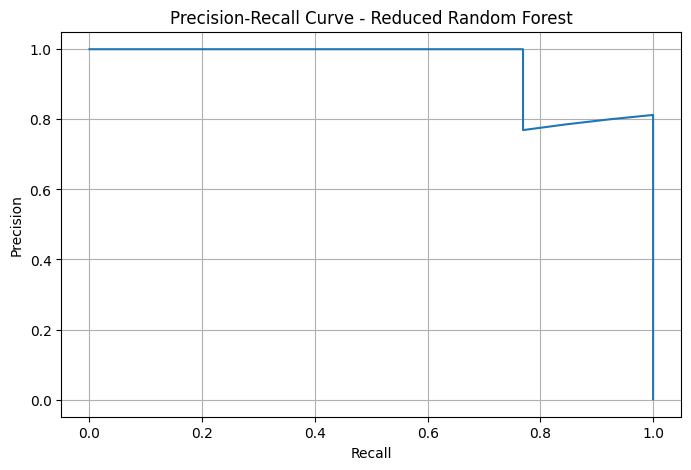

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(
    yr_val,
    yr_val_prob
)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Reduced Random Forest")
plt.grid(True)
plt.show()

In [25]:
# Predict fraud probabilities on the untouched test set
yr_test_prob = rf_reduced.predict_proba(Xr_test)[:, 1]

# Apply our selected threshold
final_threshold = 0.15

yr_test_pred = (
    yr_test_prob >= final_threshold
).astype(int)

print("Final Threshold:", final_threshold)

print("\nClassification Report:")
print(
    classification_report(
        yr_test,
        yr_test_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(yr_test, yr_test_pred))

print("\nPR-AUC:",
      average_precision_score(yr_test, yr_test_prob))

print("ROC-AUC:",
      roc_auc_score(yr_test, yr_test_prob))

Final Threshold: 0.15

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       0.82      0.69      0.75        13

    accuracy                           1.00     10000
   macro avg       0.91      0.85      0.87     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:
[[9985    2]
 [   4    9]]

PR-AUC: 0.8327091767881241
ROC-AUC: 0.9993376004190063


In [26]:
print("Actual fraud cases:", yr_test.sum())
print("Fraud cases detected:", yr_test_pred.sum())
print("Transactions flagged:", yr_test_pred.sum())

Actual fraud cases: 13
Fraud cases detected: 11
Transactions flagged: 11


In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Generate out-of-fold fraud probabilities
oof_prob = cross_val_predict(
    rf_cv,
    Xr_train,
    yr_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold predictions created.")
print("Number of training observations:", len(oof_prob))
print("Fraud cases in training:", yr_train.sum())

Out-of-fold predictions created.
Number of training observations: 80000
Fraud cases in training: 103


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.51, 0.01)

cv_results = []

for threshold in thresholds:
    predictions = (oof_prob >= threshold).astype(int)

    precision = precision_score(
        yr_train,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        yr_train,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        yr_train,
        predictions,
        zero_division=0
    )

    cv_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

cv_results = pd.DataFrame(cv_results)

print(cv_results.sort_values(
    by="F1",
    ascending=False
).head(10))

    Threshold  Precision    Recall        F1
20       0.25   0.947368  0.699029  0.804469
22       0.27   0.959459  0.689320  0.802260
23       0.28   0.959459  0.689320  0.802260
25       0.30   0.972222  0.679612  0.800000
21       0.26   0.946667  0.689320  0.797753
26       0.31   0.985714  0.669903  0.797688
27       0.32   0.985714  0.669903  0.797688
18       0.23   0.923077  0.699029  0.795580
19       0.24   0.923077  0.699029  0.795580
24       0.29   0.958904  0.679612  0.795455


In [29]:
acceptable_thresholds = cv_results[
    cv_results["Precision"] >= 0.80
].sort_values(
    by="Recall",
    ascending=False
)

print(acceptable_thresholds.head(10))

    Threshold  Precision    Recall        F1
9        0.14   0.802083  0.747573  0.773869
10       0.15   0.815217  0.728155  0.769231
11       0.16   0.840909  0.718447  0.774869
12       0.17   0.860465  0.718447  0.783069
13       0.18   0.870588  0.718447  0.787234
14       0.19   0.869048  0.708738  0.780749
15       0.20   0.878049  0.699029  0.778378
16       0.21   0.888889  0.699029  0.782609
17       0.22   0.900000  0.699029  0.786885
18       0.23   0.923077  0.699029  0.795580


In [ ]:
best_threshold_row = acceptable_thresholds.sort_values(
    by="F1",
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", best_threshold)
print("Precision:", best_threshold_row["Precision"])
print("Recall:", best_threshold_row["Recall"])
print("F1:", best_threshold_row["F1"])

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    Xr_train,
    yr_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [33]:
yr_val_prob_xgb = xgb_model.predict_proba(Xr_val)[:, 1]

yr_val_pred_xgb = (yr_val_prob_xgb >= 0.5).astype(int)

print("XGBoost Validation Results")
print("--------------------------------")
print("Accuracy :", accuracy_score(yr_val, yr_val_pred_xgb))
print("Precision:", precision_score(yr_val, yr_val_pred_xgb))
print("Recall   :", recall_score(yr_val, yr_val_pred_xgb))
print("F1 Score :", f1_score(yr_val, yr_val_pred_xgb))
print("ROC-AUC  :", roc_auc_score(yr_val, yr_val_prob_xgb))

print("\nClassification Report:")
print(classification_report(yr_val, yr_val_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(yr_val, yr_val_pred_xgb))

XGBoost Validation Results
--------------------------------
Accuracy : 0.9998
Precision: 1.0
Recall   : 0.8461538461538461
F1 Score : 0.9166666666666666
ROC-AUC  : 0.9999768930378723

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      0.85      0.92        13

    accuracy                           1.00     10000
   macro avg       1.00      0.92      0.96     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:
[[9987    0]
 [   2   11]]


In [34]:
threshold_results_xgb = []

for threshold in np.arange(0.05, 0.51, 0.01):
    pred = (yr_val_prob_xgb >= threshold).astype(int)

    precision = precision_score(yr_val, pred, zero_division=0)
    recall = recall_score(yr_val, pred, zero_division=0)
    f1 = f1_score(yr_val, pred, zero_division=0)

    threshold_results_xgb.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results_xgb = pd.DataFrame(threshold_results_xgb)

threshold_results_xgb.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
11,0.16,0.866667,1.000000,0.928571
10,0.15,0.866667,1.000000,0.928571
9,0.14,0.866667,1.000000,0.928571
8,0.13,0.866667,1.000000,0.928571
7,0.12,0.866667,1.000000,0.928571
6,0.11,0.866667,1.000000,0.928571
15,0.20,0.923077,0.923077,0.923077
16,0.21,0.923077,0.923077,0.923077
14,0.19,0.923077,0.923077,0.923077
42,0.47,1.000000,0.846154,0.916667


In [35]:
# Final XGBoost threshold selected from validation
xgb_final_threshold = 0.16

# Test probabilities
yr_test_prob_xgb = xgb_model.predict_proba(Xr_test)[:, 1]

# Apply selected threshold
yr_test_pred_xgb = (
    yr_test_prob_xgb >= xgb_final_threshold
).astype(int)

print("XGBoost Final Test Results")
print("--------------------------------")
print("Threshold:", xgb_final_threshold)
print("Accuracy :", accuracy_score(yr_test, yr_test_pred_xgb))
print("Precision:", precision_score(yr_test, yr_test_pred_xgb, zero_division=0))
print("Recall   :", recall_score(yr_test, yr_test_pred_xgb, zero_division=0))
print("F1 Score :", f1_score(yr_test, yr_test_pred_xgb, zero_division=0))
print("ROC-AUC  :", roc_auc_score(yr_test, yr_test_prob_xgb))

print("\nClassification Report:")
print(classification_report(yr_test, yr_test_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(yr_test, yr_test_pred_xgb))

XGBoost Final Test Results
--------------------------------
Threshold: 0.16
Accuracy : 0.9997
Precision: 1.0
Recall   : 0.7692307692307693
F1 Score : 0.8695652173913043
ROC-AUC  : 0.9997920373408508

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9987
           1       1.00      0.77      0.87        13

    accuracy                           1.00     10000
   macro avg       1.00      0.88      0.93     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:
[[9987    0]
 [   3   10]]


In [36]:
print("Features used by XGBoost:")
print(Xr_train.columns.tolist())

print("\nNumber of features:", Xr_train.shape[1])

print("\nTarget distribution:")
print(yr_train.value_counts())

print("\nFeature data types:")
print(Xr_train.dtypes)

Features used by XGBoost:
['step', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'balanceChangeDest', 'amountToDestBalance', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Number of features: 13

Target distribution:
isFraud
0    79897
1      103
Name: count, dtype: int64

Feature data types:
step                     int64
amount                 float64
oldbalanceOrig         float64
newbalanceOrig         float64
oldbalanceDest         float64
newbalanceDest         float64
errorBalanceDest       float64
balanceChangeDest      float64
amountToDestBalance    float64
type_CASH_OUT             bool
type_DEBIT                bool
type_PAYMENT              bool
type_TRANSFER             bool
dtype: object


In [37]:
print("Potential target-related columns:")

for col in Xr_train.columns:
    if any(word in col.lower() for word in [
        "fraud", "target", "label", "class", "is_fraud"
    ]):
        print("CHECK:", col)

Potential target-related columns:


In [38]:
import joblib

# Save trained XGBoost model
joblib.dump(xgb_model, "xgboost_fraud_model.pkl")

# Save final classification threshold
joblib.dump(xgb_final_threshold, "xgb_threshold.pkl")

# Save feature names
joblib.dump(Xr_train.columns.tolist(), "xgb_features.pkl")

print("Model saved successfully.")
print("Threshold:", xgb_final_threshold)
print("Features:", Xr_train.columns.tolist())

Model saved successfully.
Threshold: 0.16
Features: ['step', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest', 'balanceChangeDest', 'amountToDestBalance', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [39]:
final_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Threshold": [xgb_final_threshold],
    "Accuracy": [accuracy_score(yr_test, yr_test_pred_xgb)],
    "Precision": [precision_score(yr_test, yr_test_pred_xgb)],
    "Recall": [recall_score(yr_test, yr_test_pred_xgb)],
    "F1 Score": [f1_score(yr_test, yr_test_pred_xgb)],
    "ROC-AUC": [roc_auc_score(yr_test, yr_test_prob_xgb)]
})

final_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.16,0.9997,1.0,0.769231,0.869565,0.999792


In [40]:
final_results.to_csv("xgboost_final_results.csv", index=False)

print("Final results saved.")

Final results saved.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Get XGBoost feature importance
feature_importance = pd.DataFrame({
    "Feature": Xr_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
3        newbalanceOrig    0.297399
11         type_PAYMENT    0.106398
12        type_TRANSFER    0.091597
2        oldbalanceOrig    0.085423
6      errorBalanceDest    0.083759
1                amount    0.063420
8   amountToDestBalance    0.060596
9         type_CASH_OUT    0.058303
7     balanceChangeDest    0.053467
4        oldbalanceDest    0.046322
0                  step    0.029947
5        newbalanceDest    0.023369
10           type_DEBIT    0.000000


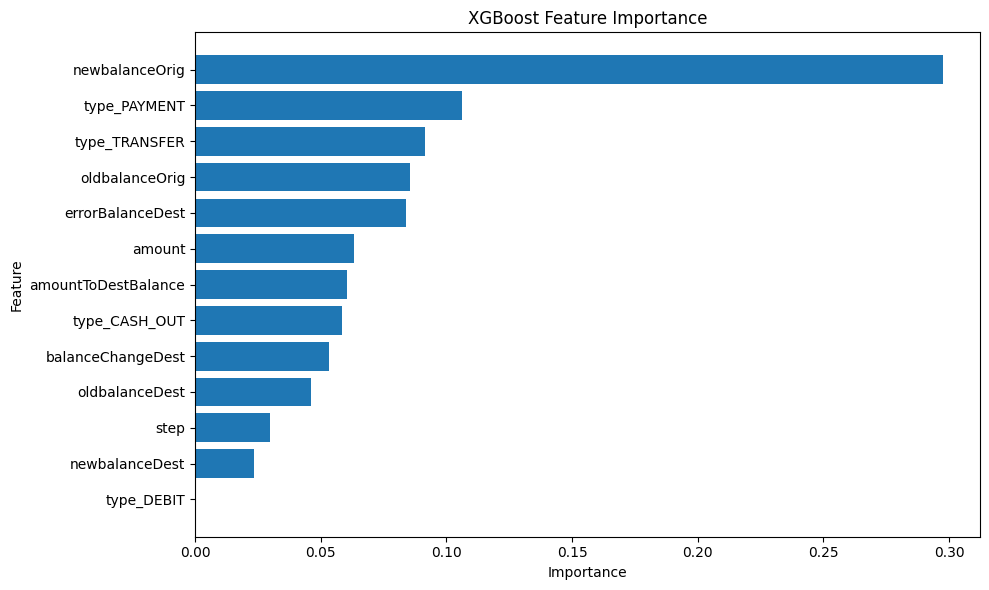

In [42]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

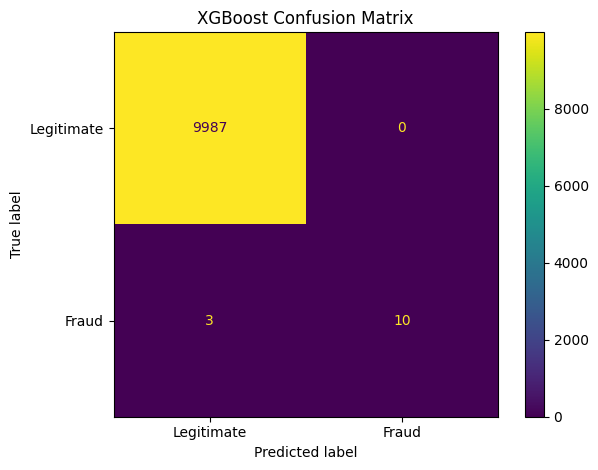

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(yr_test, yr_test_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()